In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np
import textwrap
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


## Set up the directory

In [51]:
import os
import pandas as pd

PARQUET_PATH = "../datasets/master_thesis_20000.parquet"
OUTPUT_DIR = "visualization/"

# Ensure output directory exists
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"Created output directory: {OUTPUT_DIR}")
else:
    print(f"Output directory already exists: {OUTPUT_DIR}")

# Load data
print("Loading data...")
df = pd.read_parquet(PARQUET_PATH)
deduplicated_df = df.drop_duplicates(subset=['failure_invariant'])
print("Data loaded and deduplicated successfully.")


Created output directory: visualization/
Loading data...
Data loaded and deduplicated successfully.


# Overall Analysis

## Plot Error Reasons

In [52]:
def plot_error_reasons_pie(df1, title_suffix='full_dataset'):
    top_10_percent = int(len(df1) * 0.01)
    df_invariants = df1[
        (df1['failure_invariant'].notna()) &
        df['failure_invariant'].str.strip().astype(bool) &  # Not empty or just whitespace
        (df1['failure_reason'] != "execution reverted")
    ].copy()
    #df_filtered = df_invariants[df_invariants['failure_reason'] != "execution reverted"]
    error_reasons = df_invariants['failure_invariant'].value_counts().head(20)
    
    cmap = cm.get_cmap('viridis')
    colors = [cmap(i) for i in np.linspace(0, 1, len(error_reasons))]
    

    plt.figure(figsize=(10, 10))
    plt.pie(
        error_reasons.values,
        labels=error_reasons.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors
    )
    plt.title(f'Failure Invariant for {title_suffix} dataset')
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}error_invariant_{title_suffix}.pdf", format='pdf', dpi=300)
    plt.close()

plot_error_reasons_pie(df, "full")
plot_error_reasons_pie(deduplicated_df, "deduplicated")


C:\Users\Melis\AppData\Local\Temp\ipykernel_35960\1460302730.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')
C:\Users\Melis\AppData\Local\Temp\ipykernel_35960\1460302730.py:25: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()
C:\Users\Melis\AppData\Local\Temp\ipykernel_35960\1460302730.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_invariants = df1[
C:\Users\Melis\AppData\Local\Temp\ipykernel_35960\1460302730.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.

## Most Common Invariants

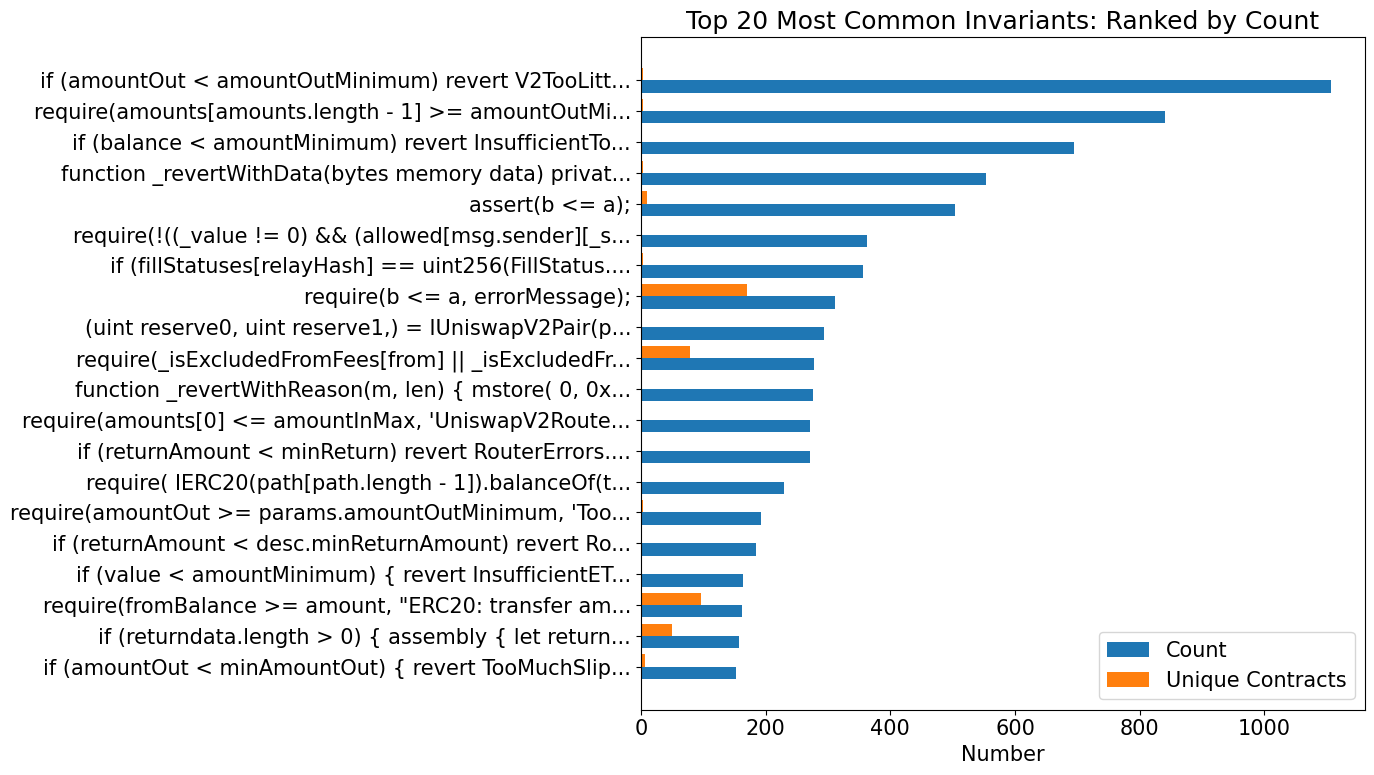

In [53]:
def plot_common_invariants_enhanced(df, max_label_length=50):
    df_invariants = df[
        (df['failure_invariant'].notna()) &
        df['failure_invariant'].str.strip().astype(bool)
    ]
    invariant_stats = df_invariants.groupby('failure_invariant').agg(
        count=('hash', 'count'),
        unique_contracts=('failure_contract', 'nunique')
    ).sort_values('count', ascending=False).head(20).reset_index()

    # Truncate failure_invariant labels if too long
    def truncate_label(label):
        return (label[:max_label_length] + '...') if len(label) > max_label_length else label

    truncated_labels = invariant_stats['failure_invariant'].apply(truncate_label)

    fig, ax = plt.subplots(figsize=(14, 8))

    width = 0.4
    x = range(len(invariant_stats))

    ax.barh([i + width/2 for i in x], invariant_stats['count'], height=width, label='Count', color='tab:blue')
    ax.barh([i - width/2 for i in x], invariant_stats['unique_contracts'], height=width, label='Unique Contracts', color='tab:orange')

    ax.set_yticks(x)
    ax.set_yticklabels(truncated_labels)
    ax.invert_yaxis()
    ax.set_xlabel('Number')
    ax.set_title('Top 20 Most Common Invariants: Ranked by Count')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}common_invariants_by_counts.pdf", format='pdf', dpi=300)
    plt.show()
    plt.close()
    
plot_common_invariants_enhanced(df)

## Gas Loss Analysis

                   failure_group  total_gas_lost  avg_gas_per_failure
0  Arithmetic Underflow/Overflow        0.060152             0.000716
1        Division/Modulo by Zero        0.003389             0.000242
2                     Invariants       18.997219             0.001482
3                 No Source Code        5.204622             0.001117
4                     Out of Gas        3.284396             0.001357


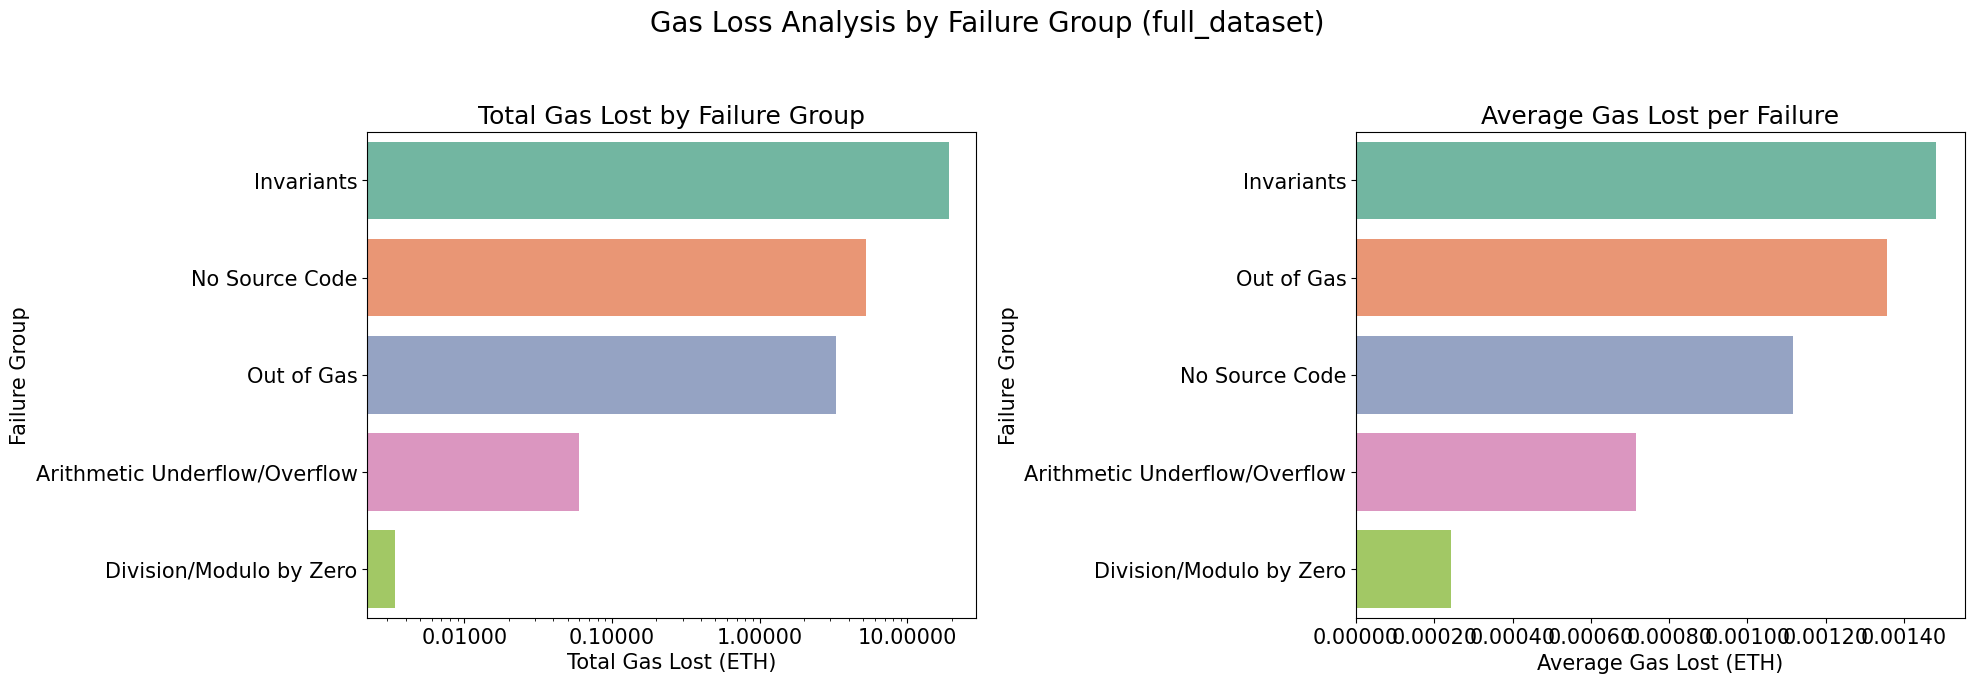

In [54]:
from matplotlib.ticker import FormatStrFormatter

def plot_gas_analysis_with_groups(df1, title_suffix='full_dataset'):
    df1 = df1.copy()
    df1['gas_loss_eth'] = (df1['gas_used'] * df1['gas_price']) / 1e18

    has_invariant = df1['failure_invariant'].notna() & df1['failure_invariant'].astype(bool)
    df1['failure_group'] = None
    df1.loc[has_invariant, 'failure_group'] = "Invariants"

    def categorize_reason(reason):
        reason_lower = reason.lower() if isinstance(reason, str) else ''
        if "out of gas" in reason_lower:
            return "Out of Gas"
        elif "no source code" in reason_lower:
            return "No Source Code"
        elif "arithmetic underflow" in reason_lower or "arithmetic overflow" in reason_lower:
            return "Arithmetic Underflow/Overflow"
        elif "division" in reason_lower and ("by zero" in reason_lower or "modulo by zero" in reason_lower):
            return "Division/Modulo by Zero"
        else:
            return "Other"

    df1.loc[~has_invariant, 'failure_group'] = df1.loc[~has_invariant, 'failure_reason'].apply(categorize_reason)

    # Aggregate metrics
    gas_analysis = df1.groupby('failure_group')['gas_loss_eth'].agg(
        total_gas_lost='sum',
        avg_gas_per_failure='mean'
    ).reset_index()
    print(gas_analysis)


    # Two different orderings
    total_order = gas_analysis.sort_values('total_gas_lost', ascending=False)['failure_group'].tolist()
    avg_order = gas_analysis.sort_values('avg_gas_per_failure', ascending=False)['failure_group'].tolist()

    plt.rcParams.update({'font.size': 15})
    fig, ax = plt.subplots(1, 2, figsize=(20, 7))
    palette = sns.color_palette("Set2", n_colors=len(gas_analysis))

    # Plot 1: Total gas lost
    sns.barplot(
        data=gas_analysis,
        x='total_gas_lost',
        y='failure_group',
        order=total_order,
        ax=ax[0],
        palette=palette
    )
    ax[0].set_title('Total Gas Lost by Failure Group')
    ax[0].set_xlabel('Total Gas Lost (ETH)')
    ax[0].set_ylabel('Failure Group')
    ax[0].set_xscale('log')
    ax[0].xaxis.set_major_formatter(FormatStrFormatter('%.5f'))

    # Plot 2: Avg gas per failure
    sns.barplot(
        data=gas_analysis,
        x='avg_gas_per_failure',
        y='failure_group',
        order=avg_order,
        ax=ax[1],
        palette=palette
    )
    ax[1].set_title('Average Gas Lost per Failure')
    ax[1].set_xlabel('Average Gas Lost (ETH)')
    ax[1].set_ylabel('Failure Group')
    ax[1].xaxis.set_major_formatter(FormatStrFormatter('%.5f'))

    plt.suptitle(f"Gas Loss Analysis by Failure Group ({title_suffix})", fontsize=20)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(f"{OUTPUT_DIR}gas_analysis.pdf", dpi=300, format='pdf')
    plt.show()
plot_gas_analysis_with_groups(df)

## Retry Behavior

Failure Reason Frequencies:

- 'no source code found': 154 times
- 'execution reverted': 49 times
- 'out of gas': 38 times
- 'Trading is not active.': 31 times
- 'ERC20: transfer amount exceeds balance': 6 times
- 'arithmetic underflow or overflow': 6 times
- 'invalid opcode: INVALID': 6 times
- '_transfer:: Trading is not active.': 6 times
- 'Lexe::approve: amount exceeds 96 bits': 5 times
- 'out of gas: not enough gas for reentrancy sentry': 5 times
- 'Blacklistable: account is blacklisted': 3 times
- 'Liquidity pair not yet created.': 3 times
- 'UniswapV2Library: INSUFFICIENT_LIQUIDITY': 3 times
- 'Already claimed': 2 times
- 'Launch / Max TxAmount 2% at launch': 2 times
- 'tradingAllowed': 2 times
- 'Trading is not enabled': 2 times
- 'Trading not active': 2 times
- 'Trading not enabled': 2 times
- 'trading not started!!!': 2 times
- 'UniswapV2Router: EXCESSIVE_INPUT_AMOUNT': 2 times
- 'Pausable: paused': 1 times
- 'ds-math-sub-underflow': 1 times
- 'Trading not open yet': 1 times


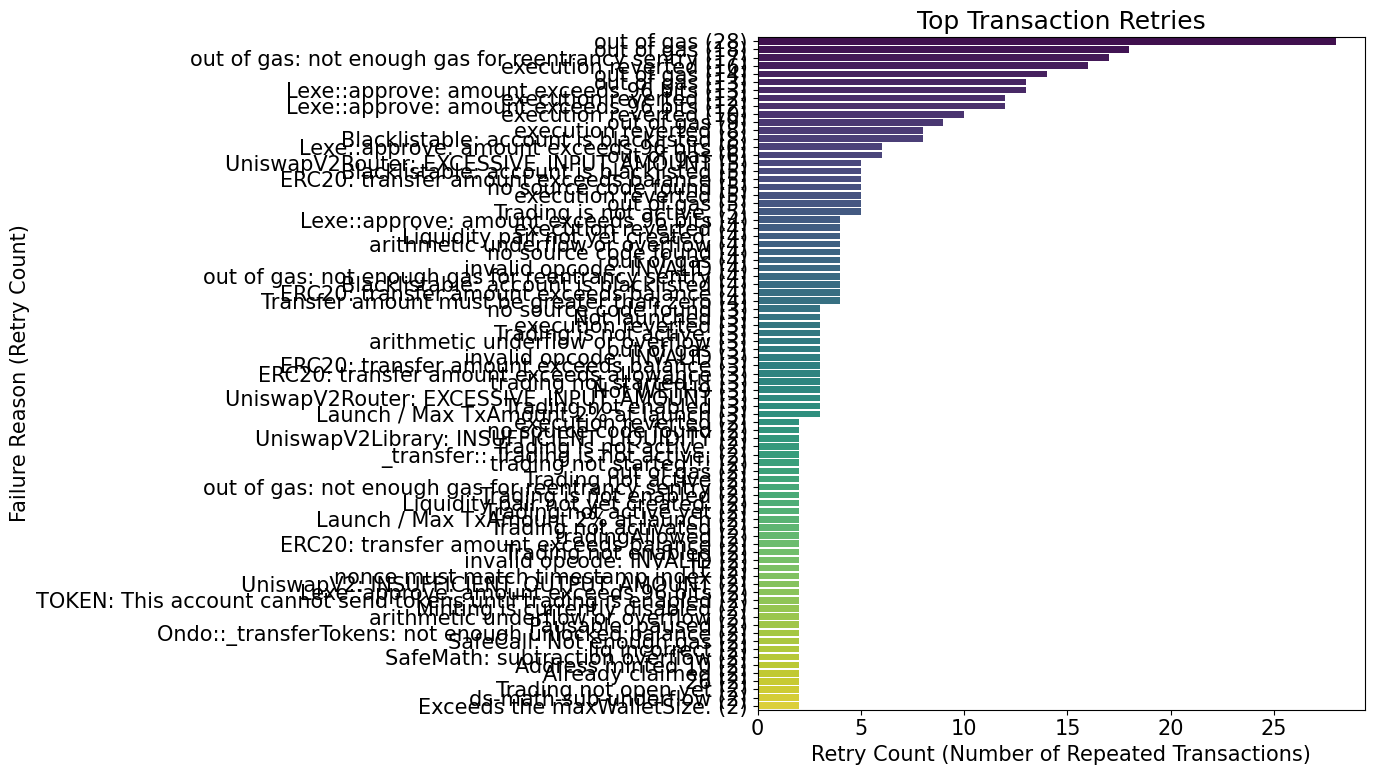

Found 352 retry groups with multiple hashes.


In [55]:
# Columns to group by for retry detection (excluding 'hash')
group_cols = ['from_address', 'to_address', 'failure_reason', 'value', 'tx_input']

#group_cols = ['failure_contract', 'failure_reason', 'failure_invariant']
# Group by these columns and collect all 'hash' values per group
retry_groups = df.groupby(group_cols).agg(
    retry_count=('hash', 'count'),           # how many transactions share these fields
    hashes=('hash', list),                    # list of hashes in this group
    unique_invariants=('failure_invariant', pd.Series.nunique),  # optional: unique invariants count
).reset_index()
retry_examples = retry_groups[retry_groups['retry_count'] > 1]
retry_examples = retry_examples.sort_values(by='retry_count', ascending=False)

import matplotlib.pyplot as plt
import seaborn as sns

failure_counts = retry_examples['failure_reason'].value_counts()

# Print each failure_reason and its count
print("Failure Reason Frequencies:\n")
for reason, count in failure_counts.items():
    print(f"- {reason!r}: {count} times")


def plot_retry_groups(retry_examples, top_n=100):
    # Take top N groups by retry_count
    top_retries = retry_examples.copy()

    # Create a concise label combining failure_reason and retry count
    top_retries['label'] = top_retries.apply(
        lambda row: f"{row['failure_reason']} ({row['retry_count']})", axis=1)

    plt.figure(figsize=(14, 8))
    sns.barplot(data=top_retries, x='retry_count', y='label', palette='viridis')

    plt.xlabel("Retry Count (Number of Repeated Transactions)")
    plt.ylabel("Failure Reason (Retry Count)")
    plt.title(f"Top Transaction Retries")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}retries.pdf", format='pdf', dpi=300)
    plt.show()

plot_retry_groups(retry_examples)


print(f"Found {len(retry_examples)} retry groups with multiple hashes.")



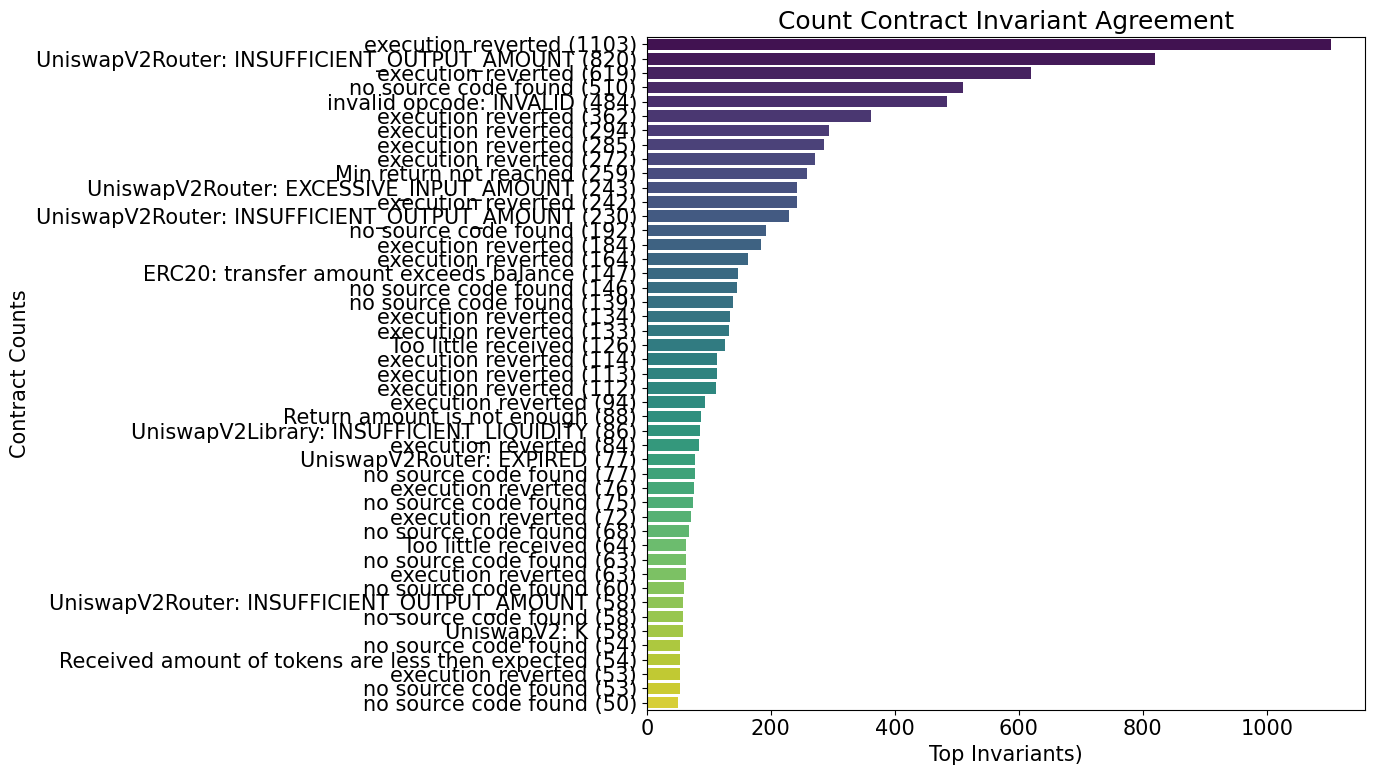

Found 1150 retry groups with multiple hashes.


In [56]:
group_cols = ['failure_contract', 'failure_reason', 'failure_invariant']
retry_groups = df.groupby(group_cols).agg(
    retry_count=('hash', 'count'),           # how many transactions share these fields
    hashes=('hash', list),                    # list of hashes in this group
    unique_invariants=('failure_invariant', pd.Series.nunique),  # optional: unique invariants count
).reset_index()
retry_examples = retry_groups[retry_groups['retry_count'] > 1]
retry_examples = retry_examples.sort_values(by='retry_count', ascending=False)

import matplotlib.pyplot as plt
import seaborn as sns

def plot_retry_groups(retry_examples, top_n=50):
    # Take top N groups by retry_count
    top_retries = retry_examples.head(top_n).copy()

    # Create a concise label combining failure_reason and retry count
    top_retries['label'] = top_retries.apply(
        lambda row: f"{row['failure_reason']} ({row['retry_count']})", axis=1)

    plt.figure(figsize=(14, 8))
    sns.barplot(data=top_retries, x='retry_count', y='label', palette='viridis')

    plt.xlabel("Top Invariants)")
    plt.ylabel("Contract Counts")
    plt.title(f"Count Contract Invariant Agreement")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}invariant_contract_agreement.pdf", format='pdf', dpi=300)
    plt.show()

plot_retry_groups(retry_examples)


print(f"Found {len(retry_examples)} retry groups with multiple hashes.")



## Source Code Verification

In [57]:
import pandas as pd

def compare_sources(df):
    df_filtered = df.copy()
    
    # Count None (or NaN) values in either column
    none_in_etherscan = df_filtered['etherscan_src'].isna()
    none_in_tenderly = df_filtered['tenderly_src'].isna()
    tenderly_none = (none_in_tenderly).sum()
    etherscan_none = (none_in_etherscan).sum()

    # Discrepancy: not equal and neither is NaN
    valid_rows = ~none_in_etherscan &  ~none_in_tenderly
    discrepancies = (df_filtered['etherscan_src'] != df_filtered['tenderly_src']) & valid_rows
    total_discrepancies = discrepancies.sum()
    ether_true = discrepancies & (df_filtered['etherscan_src'] == True) & valid_rows
    ether_true = ether_true.sum()

    tender_true = discrepancies & (df_filtered['tenderly_src'] == True) & valid_rows
    tender_true = tender_true.sum()

    print(f"Total discrepancies: {total_discrepancies}")
    print(f"Total None values in etherscan: {etherscan_none}")
    print(f"Total None values in tenderly: {tenderly_none}")
    print(f"Total discrepancies values in etherscan: {ether_true}")
    print(f"Total discrepancies values in tenderly: {tender_true}")

compare_sources(df)

Total discrepancies: 2761
Total None values in etherscan: 0
Total None values in tenderly: 2518
Total discrepancies values in etherscan: 2758
Total discrepancies values in tenderly: 3


C:\Users\Melis\AppData\Local\Temp\ipykernel_35960\696939911.py:25: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  no_keyword_mask = ~df_filtered['failure_invariant_str'].str.contains(r'\b(assert|require|revert)\b', na=False)


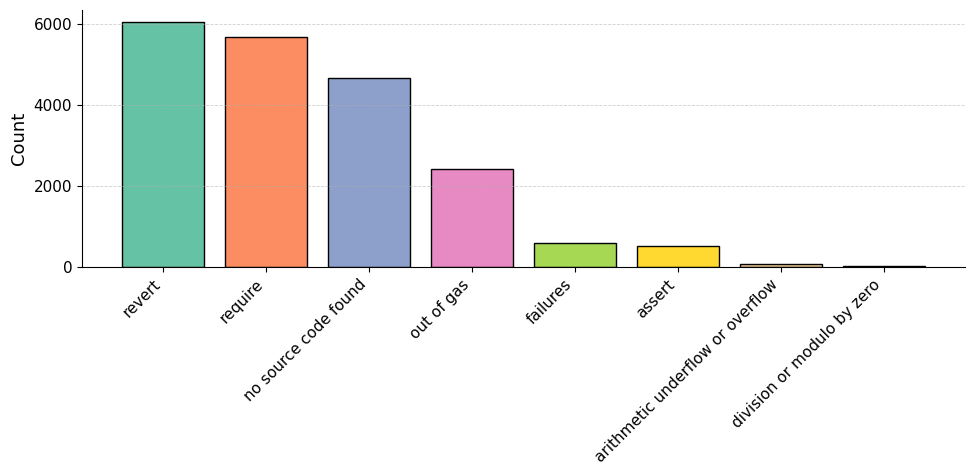


Failure Invariant Summary:
revert: 6033
require: 5660
no source code found: 4660
out of gas: 2420
failures: 600
assert: 529
arithmetic underflow or overflow: 84
division or modulo by zero: 14


In [58]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import re

def unified_failure_invariant_analysis(df):
    """
    Analyze 'failure_invariant' values by keyword usage and failure reasons.
    Produces a unified, publication-ready bar chart using the Seaborn Set2 palette.
    """
    # Step 1: Clean and normalize input
    df_filtered = df[df['failure_invariant'].notna()].copy()
    df_filtered['failure_invariant_str'] = (
        df_filtered['failure_invariant'].astype(str).str.lower().str.strip()
    )

    # Step 2: Keyword frequency analysis
    keywords = ['assert', 'require', 'revert']
    keyword_counts = {
        kw: df_filtered['failure_invariant_str'].str.contains(rf'\b{kw}\b', na=False).sum()
        for kw in keywords
    }

    # Step 3: Identify rows with no keyword and non-empty string
    no_keyword_mask = ~df_filtered['failure_invariant_str'].str.contains(r'\b(assert|require|revert)\b', na=False)
    keyword_counts['failures'] = (
        df_filtered[no_keyword_mask & (df_filtered['failure_invariant_str'] != '')].shape[0]
    )

    # Step 4: Analyze empty strings and group failure reasons
    empty_df = df_filtered[no_keyword_mask & (df_filtered['failure_invariant_str'] == '')].copy()
    empty_df['failure_reason'] = empty_df['failure_reason'].apply(
        lambda x: 'out of gas' if 'out of gas' in str(x).lower() else str(x).strip().lower()
    )
    reason_counts = empty_df['failure_reason'].value_counts().to_dict()

    # Step 5: Combine keyword and reason counts
    combined_counts = {**keyword_counts, **reason_counts}
    sorted_items = sorted(combined_counts.items(), key=lambda x: x[1], reverse=True)
    labels, values = zip(*sorted_items)

    # Step 6: Apply Seaborn Set2 palette
    palette = sns.color_palette("Set2", n_colors=len(labels))
    colors = palette[:len(labels)]

    # Step 7: Plot
    plt.figure(figsize=(10, 5))
    plt.bar(labels, values, color=colors, edgecolor='black')

    plt.ylabel('Count', fontsize=13)
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(fontsize=11)
    plt.grid(axis='y', linestyle='--', linewidth=0.6, alpha=0.6)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig("failure_invariant_set2.pdf", format='pdf')
    plt.show()

    # Optional: Print summary
    print("\nFailure Invariant Summary:")
    for label, value in sorted_items:
        print(f"{label}: {value}")
unified_failure_invariant_analysis(df)

## Plot Transactions per day

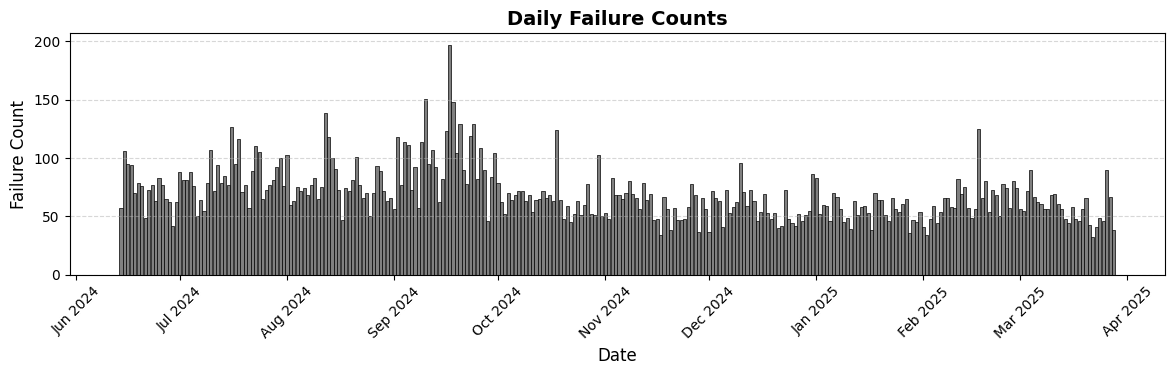

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_failure_counts_per_day(df, timestamp_col='timestamp', save_path=None):
    # Convert timestamp column to datetime
    df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors='coerce')
    df = df.dropna(subset=[timestamp_col])

    # Extract date only
    df['date'] = df[timestamp_col].dt.date

    # Count number of rows (failures) per day
    daily_counts = df.groupby('date').size()
    daily_counts.index = pd.to_datetime(daily_counts.index)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 4))  # slimmer aspect ratio for publication

    ax.bar(daily_counts.index, daily_counts.values, width=0.9, color='gray', edgecolor='black', linewidth=0.5)

    # Set x-axis to show labels once per month
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=45)

    # Add grid for readability
    ax.grid(True, which='major', axis='y', linestyle='--', alpha=0.5)

    # Set labels with publication-friendly font sizes
    ax.set_title('Daily Failure Counts', fontsize=14, weight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Failure Count', fontsize=12)
    ax.tick_params(axis='both', labelsize=10)

    plt.tight_layout()

    # Save or show
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', format='png')
    else:
        plt.show()

plot_failure_counts_per_day(df)

## String Lengths stats for unique invariants

In [48]:
# Create a string for the error message
def df_to_string(df, with_message=True):
    lines = []
    for _, row in df.iterrows():
        predicate = row['predicate']
        message = row['message']
        if with_message and pd.notnull(message):
            line = f"{predicate}, '{message}'"
        else:
            line = f"{predicate},"
        lines.append(line)
    return lines

def string_length_stats(df, with_message=True):
    strings = df_to_string(df, with_message=with_message)
    lengths = [len(s) for s in strings]

    if not lengths:
        return {"average": 0, "min": 0, "max": 0}

    average_length = sum(lengths) / len(lengths)
    min_length = min(lengths)
    max_length = max(lengths)

    return {
        "average": average_length,
        "min": min_length,
        "max": max_length
    }

file_path = "../datasets/master_thesis_20000_extracted.csv"
df_extracted = pd.read_csv(file_path)



stats_with = string_length_stats(df_extracted)

stats_without = string_length_stats(df_extracted, with_message=False)
print(f"Sting Lengths stats with error messages: {stats_with}")
print(f"Sting Lengths stats without error messages: {stats_without}")

Sting Lengths stats with error messages: {'average': 53.8707015130674, 'min': 3, 'max': 265}
Sting Lengths stats without error messages: {'average': 37.44566712517194, 'min': 3, 'max': 246}


## Error Messages Availablibity

Count with error message: 395
Count without error message: 332


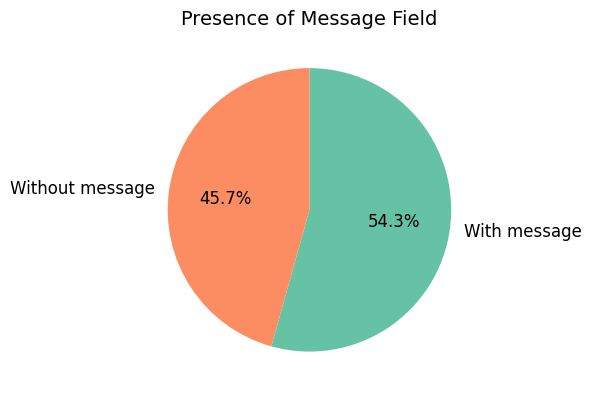

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_message_presence_pie(df):
    # Count presence vs absence of 'message'
    count_with_message = df['message'].notna().sum()
    count_without_message = df['message'].isna().sum()

    labels = ['With message', 'Without message']
    sizes = [count_with_message, count_without_message]

    # Colors: muted and academic-style
    colors = ['#66c2a5', '#fc8d62']  # from seaborn's Set2 palette

    # Pie chart
    plt.figure(figsize=(6, 6))
    wedges, texts, autotexts = plt.pie(
        sizes,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False,
        textprops={'fontsize': 12}
    )

    # Styling
    plt.title('Presence of Message Field', fontsize=14)
    plt.gca().set_aspect('equal')  # Equal aspect ratio = circular pie
    plt.tight_layout()
    print(f"Count with error message: {count_with_message}")
    print(f"Count without error message: {count_without_message}")
    # Save as vector graphic
    plt.savefig(f"{OUTPUT_DIR}message_presence_piechart.pdf", format='pdf')
    plt.show()

plot_message_presence_pie(df_extracted)